In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

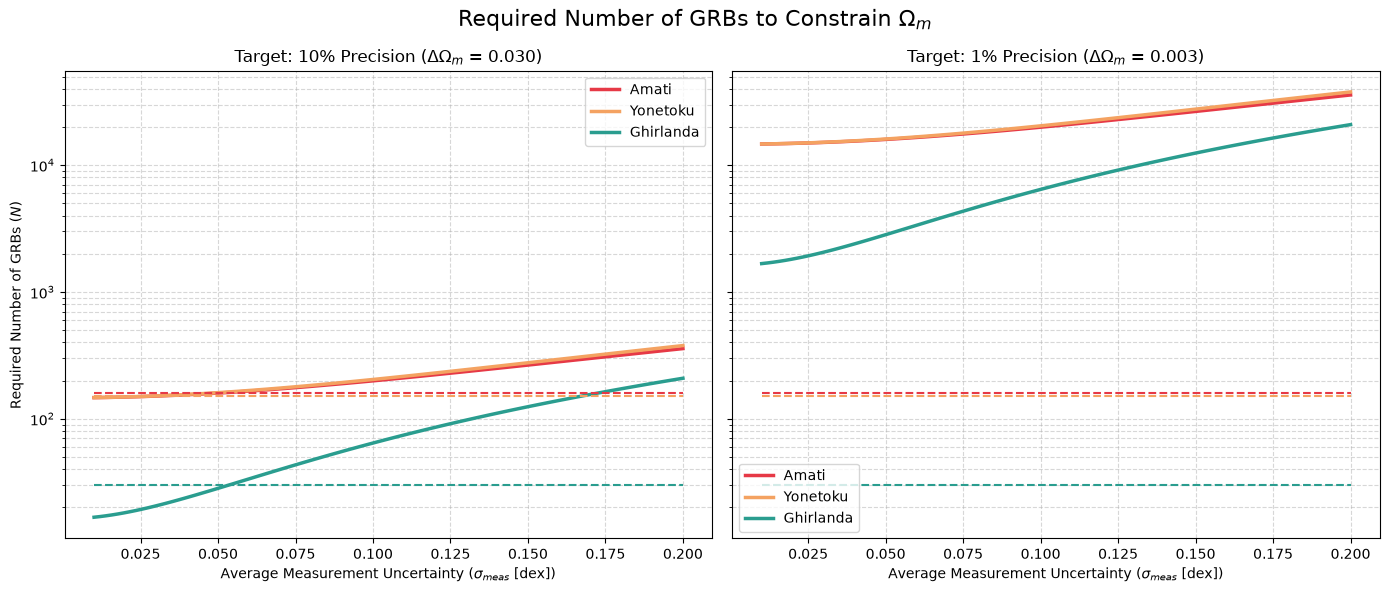

In [2]:
# --- 1. Cosmological Setup ---
H0 = 70.0 # km/s/Mpc
c = 299792.458 # km/s
Omega_m_true = 0.3

def E(z, Om):
    """Hubble parameter dimensionless function (flat LCDM)."""
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def dL(z, Om):
    """Luminosity distance in Mpc."""
    integral, _ = quad(lambda x: 1.0 / E(x, Om), 0, z)
    return (c / H0) * (1 + z) * integral

def mu(z, Om):
    """Distance modulus."""
    return 5.0 * np.log10(dL(z, Om)) + 25.0

def dmu_dOm(z, Om, dOm=0.001):
    """Numerical derivative of distance modulus w.r.t Omega_m."""
    mu_plus = mu(z, Om + dOm)
    mu_minus = mu(z, Om - dOm)
    return (mu_plus - mu_minus) / (2 * dOm)

# --- 2. Redshift Distribution & Average Derivative ---
# Assume a uniform distribution of GRBs between z=1 and z=5 for this assessment
z_array = np.linspace(1.0, 5.0, 100)
deriv_sq_array = np.array([dmu_dOm(z, Omega_m_true)**2 for z in z_array])
avg_deriv_sq = np.mean(deriv_sq_array)

# --- 3. GRB Empirical Relations Parameters ---
# Dictionaries mapping relation names to their intrinsic scatter (dex) 
# and average slope 'b'
relations = {
    'Amati': {'sigma_int': 0.30, 'b': 1.5},
    'Yonetoku': {'sigma_int': 0.30, 'b': 1.6},
    'Ghirlanda': {'sigma_int': 0.10, 'b': 1.4}
}

# --- 4. Precision Targets ---
# Target precision on Omega_m (10% and 1%)
targets = {
    '10% Precision': 0.10 * Omega_m_true,
    '1% Precision': 0.01 * Omega_m_true
}

# --- 5. Calculation over Measurement Uncertainties ---

# Average measurement uncertainty in observables (log space, dex)
sigma_meas_array = np.linspace(0.01, 0.20, 100)

# Prepare plot
fig, axes = plt.subplots(1, len(targets), 
                         figsize=(14, 6), sharey=True)
fig.suptitle(r'Required Number of GRBs to Constrain $\Omega_m$', fontsize=16)

colors = {'Amati': '#e63946', 'Yonetoku': '#f4a261', 'Ghirlanda': '#2a9d8f'}

for i, (target_name, sigma_Om_target) in enumerate(targets.items()):
    ax = axes[i]
    
    for rel_name, params in relations.items():
        sigma_int = params['sigma_int']
        b = params['b']
        
        N_required = []
        for sig_meas in sigma_meas_array:
            # Propagate error to distance modulus
            # Factor of 2 accounts for measurement error in both X and Y axis roughly
            # sigma_mu = (5/2) * sqrt(sigma_int^2 + b^2 * sigma_x^2 + sigma_y^2)
            sigma_mu = 2.5 * np.sqrt(sigma_int**2 + (b**2)*sig_meas**2 + sig_meas**2)
            
            # Fisher estimate for N
            N = (sigma_mu**2) / ((sigma_Om_target**2) * avg_deriv_sq)
            N_required.append(N)
            
        ax.plot(sigma_meas_array, N_required, label=rel_name, color=colors[rel_name], lw=2.5)
    
    ax.set_yscale('log')
    ax.set_title(fr'Target: {target_name} ($\Delta \Omega_m$ = {sigma_Om_target:.3f})')
    ax.set_xlabel(r'Average Measurement Uncertainty ($\sigma_{meas}$ [dex])')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()

# add known GRBs (low-bound)
observed_amati = 160
observed_yonetoku = 150
observed_ghirlanda = 30

for ax_id in range(len(targets)):
    axes[ax_id].hlines(observed_amati, 0.01, 0.20, linestyles="--", color=colors['Amati'])
    axes[ax_id].hlines(observed_yonetoku, 0.01, 0.20, linestyles="--", color=colors['Yonetoku'])
    axes[ax_id].hlines(observed_ghirlanda, 0.01, 0.20, linestyles="--", color=colors['Ghirlanda'])

axes[0].set_ylabel(r'Required Number of GRBs ($N$)')
plt.tight_layout()
plt.show()
fig.savefig('grb_statistics_estimations.pdf')

| GRB Relation | Key Physical Variables | Approximate Cosmological Sample Size | Limiting Observational Factor |
| --- | --- | --- | --- |
| Amati | $E_\mathrm{p, i}$ vs. Isotropic Energy ($E_\mathrm{iso}$) | $\sim 160 – 241$ GRBs | Needs spectroscopic redshift $(z)$ and time-integrated fluence. |
| Yonetoku | $E_\mathrm{p, i}$ vs. Peak Isotropic Luminosity ($L_\mathrm{iso}$) | $\sim 150 – 241$ GRBs | Needs $z$ and high-resolution 1-second peak flux data. |
| Ghirlanda | $E_\mathrm{p, i}$ vs. Collimation Energy ($E_\mathrm{\gamma}$) | $\sim 27 – 40$ GRBs | Extremely limited by the rare detection of explicit afterglow jet breaks. |

Aldowma, T. K. M., Razzaque, S., Martinelli, R., Gupta, R., Longo, F., Omodei, N., Di Lalla, N., Racusin, J. L., & Airasca, A. H. (2026). Implications of joint spectral analysis of gamma-ray bursts detected by Fermi Large Area Telescope and Gamma-ray Burst Monitor on phenomenological correlations. arXiv. https://doi.org/10.48550/arxiv.2510.16475
Cited by: 2

Cardone, V. F., Capozziello, S., & Dainotti, M. G. (2009). An updated Gamma Ray Bursts Hubble diagram. Monthly Notices of the Royal Astronomical Society, 400(2), 775-790. https://doi.org/10.1111/j.1365-2966.2009.15456.x
Cited by: 156

Deng, C., Huang, Y.-F., Xu, F., & Kurban, A. (2025). The Observed Luminosity Correlations of Gamma-Ray Bursts and Their Applications. Galaxies, 13(2), 15. https://doi.org/10.3390/galaxies13020015
Cited by: 6

Hasan, A. M., & Azzam, W. J. (2026). Do the Amati and Yonetoku Relations Evolve with Redshift for Swift GRBs?. Journal of Applied Mathematics and Physics, 14, 1106-1119. https://doi.org/10.4236/jamp.2026.143052
Cited by: 0

Lazzati, D. (2006). Long Gamma-Ray Bursts as standard candles. AIP Conference Proceedings, 836, 513-521. https://doi.org/10.1063/1.2207947
Cited by: 4

Li, L.-X. (2007). Variation of the Amati relation with cosmological redshift: a selection effect or an evolution effect?. Monthly Notices of the Royal Astronomical Society: Letters, 379(1), L55-L59. https://doi.org/10.1111/j.1745-3933.2007.00333.x
Cited by: 77

Singh, M., Singh, D., Lal Pandey, K., Verma, D., & Gupta, S. (2024). Investigating the Evolution of Amati Parameters with Redshift. Research in Astronomy and Astrophysics, 24(1), 015015. https://doi.org/10.1088/1674-4527/ad0fd5
Cited by: 4

Wang, F. Y., & Dai, Z. G. (2006). Constraining the Cosmological Parameters and Transition Redshift with Gamma-Ray Bursts and Supernovae. Monthly Notices of the Royal Astronomical Society, 368(1), 371-378. https://doi.org/10.1111/j.1365-2966.2006.10108.x
Cited by: 6